In [1]:
!git clone https://github.com/naveen-anandhan/Copper.git

fatal: destination path 'Copper' already exists and is not an empty directory.


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,accuracy_score, precision_score, recall_score


from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [4]:
%cd /content/Copper

/content/Copper


In [5]:
cooper = pd.read_csv('Copper_Set.csv')
cooper.head(3)

,id,item_date,quantity tons,customer,country,status,item type,application,thickness,width,material_ref,product_ref,delivery date,selling_price
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,20210401.0,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,DEQ1 S460MC,1670798778,20210701.0,854.00
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,20210401.0,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,0000000000000000000000000000000000104991,1668701718,20210401.0,1047.00
2,E140FF1B-2407-4C02-A0DD-780A093B1158,20210401.0,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,S0380700,628377,20210101.0,644.33


In [6]:
cooper.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181673 entries, 0 to 181672
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             181671 non-null  object 
 1   item_date      181672 non-null  float64
 2   quantity tons  181673 non-null  object 
 3   customer       181672 non-null  float64
 4   country        181645 non-null  float64
 5   status         181671 non-null  object 
 6   item type      181673 non-null  object 
 7   application    181649 non-null  float64
 8   thickness      181672 non-null  float64
 9   width          181673 non-null  float64
 10  material_ref   103754 non-null  object 
 11  product_ref    181673 non-null  int64  
 12  delivery date  181672 non-null  float64
 13  selling_price  181672 non-null  float64
dtypes: float64(8), int64(1), object(5)
memory usage: 19.4+ MB


In [7]:
# quantity tons is object
# qunatity shoube be int and remove neg

In [8]:
cooper = cooper.rename(columns={
    "quantity tons": "quantity_tons",
    "item type": "item_type",
    "delivery date": "delivery_date"
})

cooper.head(3)

,id,item_date,quantity_tons,customer,country,status,item_type,application,thickness,width,material_ref,product_ref,delivery_date,selling_price
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,20210401.0,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,DEQ1 S460MC,1670798778,20210701.0,854.00
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,20210401.0,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,0000000000000000000000000000000000104991,1668701718,20210401.0,1047.00
2,E140FF1B-2407-4C02-A0DD-780A093B1158,20210401.0,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,S0380700,628377,20210101.0,644.33


In [9]:
cooper.quantity_tons

,quantity_tons
0,54.151139
1,768.024839
2,386.127949
3,202.411065
4,785.526262
...,...
181668,102.4824216
181669,208.0864686
181670,4.235593568
181671,-2000


In [10]:
cooper["quantity_tons"] = pd.to_numeric(
    cooper["quantity_tons"], errors="coerce"
) # errors = coerece if the value not an int dont error just put Nan

cooper["quantity_tons"] = cooper["quantity_tons"].apply(
    lambda x: np.nan if x <= 0 else x
)

In [11]:
cooper.head(3)

,id,item_date,quantity_tons,customer,country,status,item_type,application,thickness,width,material_ref,product_ref,delivery_date,selling_price
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,20210401.0,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,DEQ1 S460MC,1670798778,20210701.0,854.00
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,20210401.0,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,0000000000000000000000000000000000104991,1668701718,20210401.0,1047.00
2,E140FF1B-2407-4C02-A0DD-780A093B1158,20210401.0,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,S0380700,628377,20210101.0,644.33


In [12]:
cooper["item_date"] = pd.to_datetime(
    cooper["item_date"], format="%Y%m%d", errors="coerce"
)

cooper["delivery_date"] = pd.to_datetime(
    cooper["delivery_date"], format="%Y%m%d", errors="coerce"
)

cooper.head(3)

,id,item_date,quantity_tons,customer,country,status,item_type,application,thickness,width,material_ref,product_ref,delivery_date,selling_price
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,2021-04-01,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,DEQ1 S460MC,1670798778,2021-07-01,854.00
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,2021-04-01,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,0000000000000000000000000000000000104991,1668701718,2021-04-01,1047.00
2,E140FF1B-2407-4C02-A0DD-780A093B1158,2021-04-01,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,S0380700,628377,2021-01-01,644.33


In [13]:
cooper["material_ref"]

,material_ref
0,DEQ1 S460MC
1,0000000000000000000000000000000000104991
2,S0380700
3,DX51D+ZM310MAO 2.3X1317
4,2_S275JR+AR-CL1
...,...
181668,0000000000000000000000000000000001000777
181669,0000000000000000000000000000000001000227
181670,0000000000000000000000000000000001004216
181671,0000000000000000000000000000000001001149


In [14]:
cooper["material_ref"] = (
    cooper["material_ref"]
    .str.strip("0")
    .str.replace(r"[_+-]", "", regex=True) # replace - _ + with ""
    .fillna("Unknown")
    .astype("category")
)
cooper.head(3)

,id,item_date,quantity_tons,customer,country,status,item_type,application,thickness,width,material_ref,product_ref,delivery_date,selling_price
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,2021-04-01,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,DEQ1 S460MC,1670798778,2021-07-01,854.00
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,2021-04-01,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,104991,1668701718,2021-04-01,1047.00
2,E140FF1B-2407-4C02-A0DD-780A093B1158,2021-04-01,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,S03807,628377,2021-01-01,644.33


In [15]:
cooper.isnull().sum()

,0
id,2
item_date,3
quantity_tons,5
customer,1
country,28
status,2
item_type,0
application,24
thickness,1
width,0


In [16]:
def fill_na_values(df):
    median_col = [
        'quantity_tons', 'customer', 'country',
        'application', 'width', 'selling_price', 'thickness']

    for col in median_col:
        df[col] = df[col].apply(lambda x: np.nan if x <= 0 else x)   # if the values == 0 or val == neg value
        df[col] = df[col].fillna(df[col].median()) # if the valu is Nan fill with median

    mode_col = ['item_date', 'delivery_date', 'status']

    for col in mode_col:
        df[col] = df[col].fillna(df[col].mode().iloc[0]) # take the first if clash

    return df

In [17]:
cooper = fill_na_values(cooper)

In [18]:
cooper[['item_date', 'delivery_date']]

,item_date,delivery_date
0,2021-04-01,2021-07-01
1,2021-04-01,2021-04-01
2,2021-04-01,2021-01-01
3,2021-04-01,2021-01-01
4,2021-04-01,2021-03-01
...,...,...
181668,2020-07-02,2020-07-01
181669,2020-07-02,2020-07-01
181670,2020-07-02,2020-07-01
181671,2020-07-02,2020-07-01


In [19]:
cooper.isnull().sum()

,0
id,2
item_date,0
quantity_tons,0
customer,0
country,0
status,0
item_type,0
application,0
thickness,0
width,0


In [20]:
cooper = cooper.dropna()

In [21]:
cooper.head(2)

,id,item_date,quantity_tons,customer,country,status,item_type,application,thickness,width,material_ref,product_ref,delivery_date,selling_price
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,2021-04-01,54.151139,30156308.0,28.0,Won,W,10.0,2.0,1500.0,DEQ1 S460MC,1670798778,2021-07-01,854.0
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,2021-04-01,768.024839,30202938.0,25.0,Won,W,41.0,0.8,1210.0,104991,1668701718,2021-04-01,1047.0


In [22]:
cooper.dtypes

,0
id,object
item_date,datetime64[ns]
quantity_tons,float64
customer,float64
country,float64
status,object
item_type,object
application,float64
thickness,float64
width,float64


In [23]:
cooper["country"] = cooper["country"].astype("int32") # Convert data types

In [24]:
cooper = cooper.drop(columns=["id", "material_ref"]) #Drop unwanted columns

In [25]:
cooper.head(3)

,item_date,quantity_tons,customer,country,status,item_type,application,thickness,width,product_ref,delivery_date,selling_price
0,2021-04-01,54.151139,30156308.0,28,Won,W,10.0,2.00,1500.0,1670798778,2021-07-01,854.00
1,2021-04-01,768.024839,30202938.0,25,Won,W,41.0,0.80,1210.0,1668701718,2021-04-01,1047.00
2,2021-04-01,386.127949,30153963.0,30,Won,WI,28.0,0.38,952.0,628377,2021-01-01,644.33


In [26]:
cooper.info()
cooper.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 181671 entries, 0 to 181672
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   item_date      181671 non-null  datetime64[ns]
 1   quantity_tons  181671 non-null  float64       
 2   customer       181671 non-null  float64       
 3   country        181671 non-null  int32         
 4   status         181671 non-null  object        
 5   item_type      181671 non-null  object        
 6   application    181671 non-null  float64       
 7   thickness      181671 non-null  float64       
 8   width          181671 non-null  float64       
 9   product_ref    181671 non-null  int64         
 10  delivery_date  181671 non-null  datetime64[ns]
 11  selling_price  181671 non-null  float64       
dtypes: datetime64[ns](2), float64(6), int32(1), int64(1), object(2)
memory usage: 17.3+ MB


,0
item_date,0
quantity_tons,0
customer,0
country,0
status,0
item_type,0
application,0
thickness,0
width,0
product_ref,0


In [27]:
cooper.head()

,item_date,quantity_tons,customer,country,status,item_type,application,thickness,width,product_ref,delivery_date,selling_price
0,2021-04-01,54.151139,30156308.0,28,Won,W,10.0,2.00,1500.0,1670798778,2021-07-01,854.00
1,2021-04-01,768.024839,30202938.0,25,Won,W,41.0,0.80,1210.0,1668701718,2021-04-01,1047.00
2,2021-04-01,386.127949,30153963.0,30,Won,WI,28.0,0.38,952.0,628377,2021-01-01,644.33
3,2021-04-01,202.411065,30349574.0,32,Won,S,59.0,2.30,1317.0,1668701718,2021-01-01,768.00
4,2021-04-01,785.526262,30211560.0,28,Won,W,10.0,4.00,2000.0,640665,2021-03-01,577.00


EDA

In [28]:
EDA = cooper.copy(True)
EDA.head(6)

,item_date,quantity_tons,customer,country,status,item_type,application,thickness,width,product_ref,delivery_date,selling_price
0,2021-04-01,54.151139,30156308.0,28,Won,W,10.0,2.00,1500.0,1670798778,2021-07-01,854.00
1,2021-04-01,768.024839,30202938.0,25,Won,W,41.0,0.80,1210.0,1668701718,2021-04-01,1047.00
2,2021-04-01,386.127949,30153963.0,30,Won,WI,28.0,0.38,952.0,628377,2021-01-01,644.33
3,2021-04-01,202.411065,30349574.0,32,Won,S,59.0,2.30,1317.0,1668701718,2021-01-01,768.00
4,2021-04-01,785.526262,30211560.0,28,Won,W,10.0,4.00,2000.0,640665,2021-03-01,577.00
5,2021-04-01,225.790676,30202938.0,25,Won,W,41.0,1.50,1265.0,1668701718,2021-04-01,983.00


In [29]:
EDA.describe().T

,count,mean,min,25%,50%,75%,max,std
item_date,181671,2020-11-26 22:56:12.492032256,2020-07-02 00:00:00,2020-09-29 00:00:00,2020-11-30 00:00:00,2021-02-03 00:00:00,2021-04-01 00:00:00,NaN
quantity_tons,181671.0,5874.969829,0.00001,10.971527,30.365013,67.16084,1000000000.0,2349087.706833
customer,181671.0,30512210.39167,12458.0,30196884.0,30205242.0,30280416.0,2147483647.0,24333882.549455
country,181671.0,44.890918,25.0,26.0,30.0,78.0,113.0,24.4031
application,181671.0,25.614308,2.0,10.0,15.0,41.0,99.0,17.753309
thickness,181671.0,2.56483,0.18,0.7,1.5,3.0,2500.0,6.572338
width,181671.0,1295.2902,1.0,1180.0,1250.0,1500.0,2990.0,261.631087
product_ref,181671.0,473973121.700002,611728.0,611993.0,640665.0,1332077137.0,1722207579.0,717512295.362016
delivery_date,181671,2021-01-25 22:43:03.020955136,2019-04-01 00:00:00,2020-11-01 00:00:00,2021-01-01 00:00:00,2021-04-01 00:00:00,2022-01-01 00:00:00,NaN
selling_price,181671.0,1918.086978,0.1,669.0,812.0,953.0,100001015.0,331796.55548


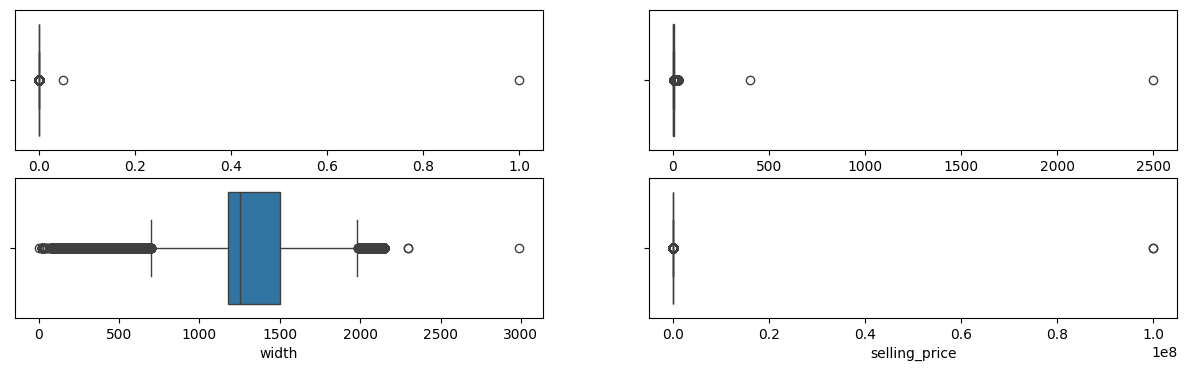

In [30]:
fig, axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(15,4)

a = sns.boxplot(EDA['quantity_tons'], orient = "h" , ax=axes[0][0])
a = sns.boxplot(EDA['thickness'] , orient = "h" , ax=axes[0][1])
a = sns.boxplot(EDA['width'] , orient = "h" , ax=axes[1][0])
a = sns.boxplot(EDA['selling_price'] , orient = "h" , ax=axes[1][1])

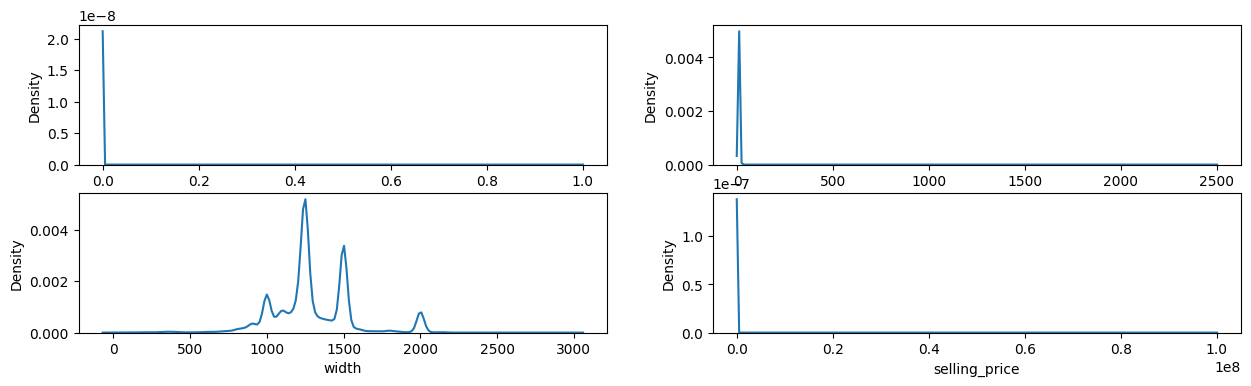

In [31]:
fig, axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(15,4)
a = sns.kdeplot(EDA['quantity_tons'] , ax=axes[0][0])
a = sns.kdeplot(EDA['thickness'] , ax=axes[0][1])
a = sns.kdeplot(EDA['width'] , ax=axes[1][0])
a = sns.kdeplot(EDA['selling_price'] , ax=axes[1][1])

In [32]:
outlier_columns = ['quantity_tons', 'thickness', 'width', 'selling_price']
before_stats = EDA[outlier_columns].describe().T
before_stats

,count,mean,std,min,25%,50%,75%,max
quantity_tons,181671.0,5874.969829,2.349088e+06,0.00001,10.971527,30.365013,67.16084,1.000000e+09
thickness,181671.0,2.564830,6.572338e+00,0.18000,0.700000,1.500000,3.00000,2.500000e+03
width,181671.0,1295.290200,2.616311e+02,1.00000,1180.000000,1250.000000,1500.00000,2.990000e+03
selling_price,181671.0,1918.086978,3.317966e+05,0.10000,669.000000,812.000000,953.00000,1.000010e+08


In [33]:
for column in outlier_columns:
    Q1 = EDA[column].quantile(0.25)
    Q3 = EDA[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    EDA[column] = EDA[column].clip(lower_bound, upper_bound)

# Calculate summary statistics after removing outliers
after_stats = EDA[outlier_columns].describe().T

after_stats

,count,mean,std,min,25%,50%,75%,max
quantity_tons,181671.0,49.176066,47.992448,0.00001,10.971527,30.365013,67.16084,151.444809
thickness,181671.0,2.245431,1.890714,0.18000,0.700000,1.500000,3.00000,6.450000
width,181671.0,1297.049079,248.961064,700.00000,1180.000000,1250.000000,1500.00000,1980.000000
selling_price,181671.0,819.073709,209.124735,243.00000,669.000000,812.000000,953.00000,1379.000000


In [ ]:
# Q1 = 10.97
# Q3 = 67.16

# IQR = 67.16 - 10.97
#     = 56.19


# Lower bound:
# 10.97 - (1.5 × 56.19)
# = 10.97 - 84.29
# = -73.32

# Upper bound:
# 67.16 + (1.5 × 56.19)
# = 151.44

# -73.32  -------- 151.44

In [33]:
fig, axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(15,4)

a = sns.boxplot(EDA['quantity_tons'] , orient = "h" , ax=axes[0][0])
a = sns.boxplot(EDA['thickness'] , orient = "h" , ax=axes[0][1])
a = sns.boxplot(EDA['width'] , orient = "h" , ax=axes[1][0])
a = sns.boxplot(EDA['selling_price'] , orient = "h" , ax=axes[1][1])

<Axes: >

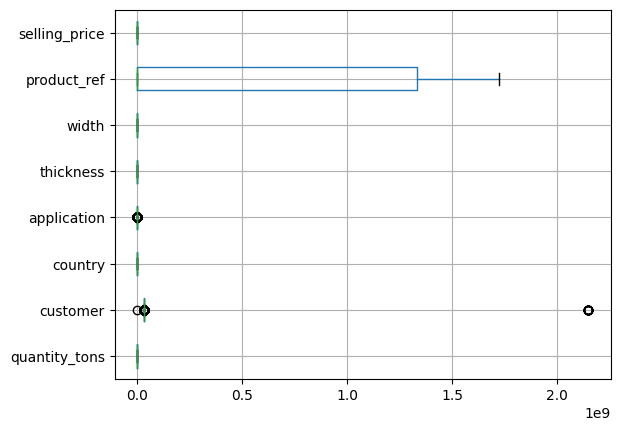

In [35]:
EDA.boxplot(vert=False)

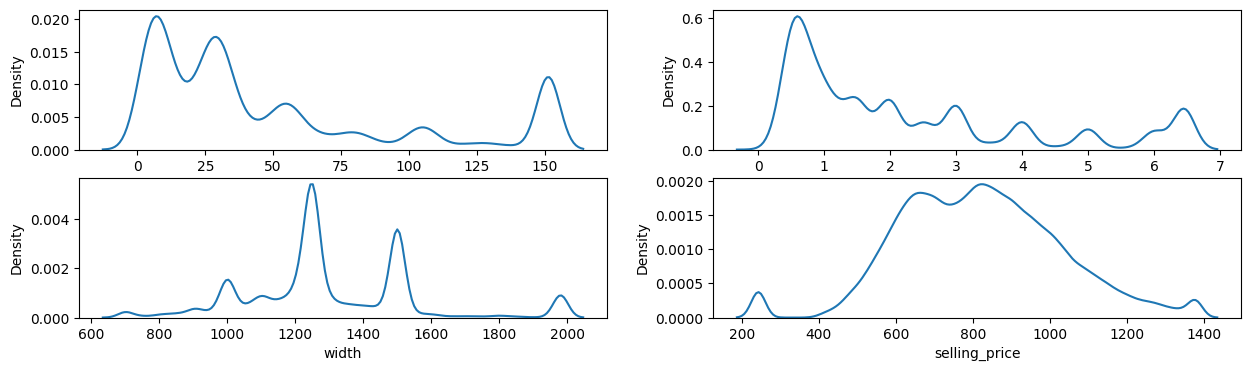

In [36]:
fig, axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(15,4)
a = sns.kdeplot(EDA['quantity_tons'] , ax=axes[0][0])
a = sns.kdeplot(EDA['thickness'] , ax=axes[0][1])
a = sns.kdeplot(EDA['width'] , ax=axes[1][0])
a = sns.kdeplot(EDA['selling_price'] , ax=axes[1][1])

In [37]:
print(EDA["quantity_tons"].skew())
print(EDA["thickness"].skew())
print(EDA["width"].skew())
print(EDA["selling_price"].skew())

1.1217808125912514
1.0609376657739789
0.6676540138505562
0.13709024365587272


In [ ]:
# To Treate the Skewness using yeojohnson from scipy

In [ ]:
# λ = 2      → x²
# λ = 1      → x
# λ = 0.5    → √x
# λ = 0      → behaves similar to log(x)

In [38]:
from scipy import stats

columns_to_transform = ['quantity_tons','thickness','selling_price']

for col in columns_to_transform:
    EDA[f'{col}_yeojohnson'], _ = stats.yeojohnson(EDA[col])
    print(f"Skewness of {col}_yeojohnson: {EDA[f'{col}_yeojohnson'].skew()}")

Skewness of quantity_tons_yeojohnson: -0.04912377079026545
Skewness of thickness_yeojohnson: 0.13505621598059844
Skewness of selling_price_yeojohnson: 0.0360357577588512


| Feature                                       | Log                | Yeo-Johnson |
| --------------------------------------------- | ------------------ | ----------- |
| Positive values                               | ✅                  | ✅           |
| Zero values                                   | ❌ (`log(0)` fails) | ✅           |
| Negative values                               | ❌                  | ✅           |
| Automatically chooses the best transformation | ❌                  | ✅           |


In [39]:
EDA.head(3)

,item_date,quantity_tons,customer,country,status,item_type,application,thickness,width,product_ref,delivery_date,selling_price,quantity_tons_yeojohnson,thickness_yeojohnson,selling_price_yeojohnson
0,2021-04-01,54.151139,30156308.0,28,Won,W,10.0,2.00,1500.0,1670798778,2021-07-01,854.00,5.595642,0.816471,469.292486
1,2021-04-01,151.444809,30202938.0,25,Won,W,41.0,0.80,1210.0,1668701718,2021-04-01,1047.00,7.672763,0.499457,563.295510
2,2021-04-01,151.444809,30153963.0,30,Won,WI,28.0,0.38,952.0,628377,2021-01-01,644.33,7.672763,0.294248,364.571775


## FEATURE ENGINEERING

In [40]:
data=EDA.copy(True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 181671 entries, 0 to 181672
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   item_date                 181671 non-null  datetime64[ns]
 1   quantity_tons             181671 non-null  float64       
 2   customer                  181671 non-null  float64       
 3   country                   181671 non-null  int32         
 4   status                    181671 non-null  object        
 5   item_type                 181671 non-null  object        
 6   application               181671 non-null  float64       
 7   thickness                 181671 non-null  float64       
 8   width                     181671 non-null  float64       
 9   product_ref               181671 non-null  int64         
 10  delivery_date             181671 non-null  datetime64[ns]
 11  selling_price             181671 non-null  float64       
 12  quantit

In [ ]:
columns_of_interest = ['item_date','delivery_date','customer','country','application','width','product_ref','selling_price_yeojohnson','quantity_tons_yeojohnson','thickness_yeojohnson','delivery_time_taken']
corr=data[columns_of_interest].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size":8})
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# hypothesis
# "The number of days between ordering and delivery might influence the selling price or status."

data['delivery_time_taken']=(data['item_date']-data['delivery_date']).abs().dt.days

In [41]:
data.drop(columns=['quantity_tons','thickness','selling_price','delivery_date','item_date'], inplace=True)

data.head(3)

,customer,country,status,item_type,application,width,product_ref,quantity_tons_yeojohnson,thickness_yeojohnson,selling_price_yeojohnson
0,30156308.0,28,Won,W,10.0,1500.0,1670798778,5.595642,0.816471,469.292486
1,30202938.0,25,Won,W,41.0,1210.0,1668701718,7.672763,0.499457,563.295510
2,30153963.0,30,Won,WI,28.0,952.0,628377,7.672763,0.294248,364.571775


## FINDING UNIQUE VALUE

In [ ]:

# they all are str

data['country'] = data['country'].astype('str')
country=data['country'].unique()
status=data['status'].unique()
item=data['item_type'].unique()
print(country)
print(status)
print(item)

## ENCODE THE CATEGORICAL COLUMN

In [ ]:
from sklearn.preprocessing import OrdinalEncoder


# ordinal means 1 2 3

encode = OrdinalEncoder()
data["country"] = encode.fit_transform(data[["country"]])
transformed_country = data["country"].unique()

data['status'] = encode.fit_transform(data[['status']])
transformed_status = data['status'].unique()

data["item_type"] = encode.fit_transform(data[["item_type"]])
transformed_item = data["item_type"].unique()

In [ ]:
import pickle

file_path='country.pkl'
file_path2='status.pkl'
file_path3='item_type.pkl'

with open(file_path, 'wb') as file:
    pickle.dump(transformed_country, file)
with open(file_path2, 'wb') as file:
    pickle.dump(transformed_status, file)
with open(file_path3, 'wb') as file:
    pickle.dump(transformed_item, file)

print(f'Pickle file created: {file_path}, {file_path2},{file_path3}')

In [ ]:
data.head(3)

In [ ]:
from sklearn import preprocessing

X = data[['quantity_tons_yeojohnson','thickness_yeojohnson','width','status','country','item_type','application','product_ref','delivery_time_taken']].values
y = data[['selling_price_yeojohnson']].values

scalled_data = StandardScaler().fit(X)
X = scalled_data.transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
with open('scaling.pkl', 'wb') as file:
    pickle.dump(scalled_data, file)

In [ ]:
# When should you use it?

# ✅ Use StandardScaler for:

# Logistic Regression
# Linear Regression
# SVM
# KNN
# Neural Networks
# PCA

# ❌ Usually not needed for:

# Decision Tree
# Random Forest
# XGBoost
# LightGBM
# CatBoost

In [ ]:
models = {"ExtraTreeRegressor" : ExtraTreesRegressor(),
          'XGBRegressor' : XGBRegressor(),
          'DecisionTreeRegressor': DecisionTreeRegressor()
}
n = X_test.shape[0]  # number of rows
p = X_test.shape[1]  # number of freatures

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    MSE = mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)
    Adjusted_R2 = 1 - ((1 - R2) * (n - 1) / (n - p - 1))

    print("+----------------------------------+")
    print(f"   -- {list(models.keys())[i]} --    ")
    print("+----------------------------------+")
    print("| Model performance on testing set |")
    print("+----------------------------------+")
    print("|         MSE :{:.4f}           |".format(MSE))
    print("|         MAE :{:.4f}             |".format(MAE))
    print("|         R2  :{:.4f}              |".format(R2))
    print("| Adjusted R2 : {:.4f}             |".format(Adjusted_R2))
    print("+----------------------------------+")
    print(f'='*36)

In [ ]:
# Hyperparmeter Tuaining

from sklearn.model_selection import GridSearchCV

ET_param_grid = {
    'n_estimators': [100],
    'max_depth': [10, None],
    'min_samples_split': [2,10],
    'min_samples_leaf': [1, 2,],
    'max_features': ['sqrt', 'log2']
}
gridcv_models = [("ET", ExtraTreesRegressor(), ET_param_grid )]
gridcv_models

In [ ]:
model_param = {}
for name, model, params in gridcv_models:
    grid_search  = GridSearchCV(estimator=model,
                               param_grid=params,
                               cv=3,
                               verbose=2,
                               n_jobs=-1
                              )
    grid_search.fit(X_train, y_train)
    model_param[name] = grid_search.best_params_

for model_name in model_param:
    print(f"===========Best Params for {model_name}===========")
    print(model_param[model_name])

In [ ]:
models = {
    'ExtraTreeRegression' : ExtraTreesRegressor()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    MSE = mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)
    Adjusted_R2 = 1 - ((1 - R2) * (n - 1) / (n - p - 1))

    print("+----------------------------------+")
    print(f"   -- {list(models.keys())[i]} --    ")
    print("+----------------------------------+")
    print("| Model performance on testing set |")
    print("+----------------------------------+")
    print("|         MSE :{:.4f}           |".format(MSE))
    print("|         MAE :{:.4f}             |".format(MAE))
    print("|         R2  :{:.4f}              |".format(R2))
    print("| Adjusted R2 : {:.4f}             |".format(Adjusted_R2))
    print("+----------------------------------+")
    print(f'='*36)

In [ ]:
et_model = ExtraTreesRegressor()
et_model_reg=et_model.fit(X_train, y_train)

with open('et_reg.pkl', 'wb') as file:
    pickle.dump(et_model_reg, file)

with open('et_reg.pkl', 'rb') as file:
    et_reg = pickle.load(file)

In [ ]:
country_to_transformed = dict(zip(country, transformed_country))
item_to_transformed = dict(zip(item, transformed_item))
status_to_transformed = dict(zip(status, transformed_status))

# # Function to transform input based on mappings
# def get_transformed_value(value, original_list, transformed_list):
#     try:
#         return transformed_list[original_list.index(value)]
#     except ValueError:
#         print(f"{value} not found in list.")
#         return None


# Lookup for country
new_sample_co = input("Enter a country: ")
c = country_to_transformed.get(new_sample_co)
if c is None:
    print("Country not found.")
    exit()

# Lookup for item type
new_sample_it = input("Enter an item type: ")
it = item_to_transformed.get(new_sample_it)

if it is None:
    print("item type not found.")
    exit()

# Lookup for status
new_sample_st = input("Enter a status: ")
s = status_to_transformed.get(new_sample_st)

if s is None:
    print("ststus not found.")
    exit()

# Testing prediction
try:
    x = [5.594940, 0.816394, 1500, s, c, it, 10.0, 1670798778, 91]
    x = np.array(x).reshape(1, -1)  # Reshape to 2D array
    new_sample_scaled = scalled_data.transform(x)
    new_pred = et_model.predict(new_sample_scaled)
    print('Predicted selling price:', new_pred)
except Exception as e:
    print(f"Error: {e}. Please enter valid values to ML model.")

## Classification Model

In [ ]:
x = data[[ 'quantity_tons_yeojohnson','thickness_yeojohnson','width','selling_price_yeojohnson','country','item_type','application','product_ref','delivery_time_taken']].values
Y = data[['status']].values

scaler_classify = StandardScaler().fit(x)
x = scaler_classify.transform(x)

# Split the dataset into training and testing sets
x_train, x_test, Y_train, Y_test = train_test_split(x, Y, test_size=0.3, random_state=20)

In [ ]:
with open('scaling_classify.pkl', 'wb') as file:
    pickle.dump(scaler_classify, file)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
models = {"RandomForestClassifier" : RandomForestClassifier(),             # Random Forest Classifier
          'XGBClassifier' : xgb.XGBClassifier(),
          'DecisionTreeClassifier': DecisionTreeClassifier()
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, Y_train)

    # Predictions
    Y_train_pred = model.predict(x_train)
    Y_test_pred = model.predict(x_test)

    # Training metrics
    train_accuracy = accuracy_score(Y_train, Y_train_pred)
    train_precision = precision_score(Y_train, Y_train_pred, average='weighted')
    train_recall = recall_score(Y_train, Y_train_pred, average='weighted')
    train_f1 = f1_score(Y_train, Y_train_pred, average='weighted')

    # Testing metrics
    test_accuracy = accuracy_score(Y_test, Y_test_pred)
    test_precision = precision_score(Y_test, Y_test_pred, average='weighted')
    test_recall = recall_score(Y_test, Y_test_pred, average='weighted')
    test_f1 = f1_score(Y_test, Y_test_pred, average='weighted')

    print("+----------------------------------+")
    print(f"   -- {list(models.keys())[i]} --    ")
    print("+----------------------------------+")
    print("| Model performance on training set |")
    print("+----------------------------------+")
    print(f"|   Accuracy: {train_accuracy:.4f}               |")
    print(f"|   Precision: {train_precision:.4f}              |")
    print(f"|   Recall: {train_recall:.4f}                 |")
    print(f"|   F1 Score: {train_f1:.4f}               |")
    print("+----------------------------------+")
    print("| Model performance on testing set |")
    print("+----------------------------------+")
    print(f"|   Accuracy: {test_accuracy:.4f}               |")
    print(f"|   Precision: {test_precision:.4f}              |")
    print(f"|   Recall: {test_recall:.4f}                 |")
    print(f"|   F1 Score: {test_f1:.4f}               |")
    print(f'='*50)

In [ ]:
# +----------------------------------+
#    -- RandomForestClassifier --
# +----------------------------------+
# | Model performance on training set |
# +----------------------------------+
# |   Accuracy: 1.0000               |
# |   Precision: 1.0000              |
# |   Recall: 1.0000                 |
# |   F1 Score: 1.0000               |
# +----------------------------------+
# | Model performance on testing set |
# +----------------------------------+
# |   Accuracy: 0.9147               |
# |   Precision: 0.9132              |
# |   Recall: 0.9147                 |
# |   F1 Score: 0.9127               |
# ====================================
# +----------------------------------+
#    -- XGBClassifier --
# +----------------------------------+
# | Model performance on training set |
# +----------------------------------+
# |   Accuracy: 0.8587               |
# |   Precision: 0.8565              |
# |   Recall: 0.8587                 |
# |   F1 Score: 0.8529               |
# +----------------------------------+
# | Model performance on testing set |
# +----------------------------------+
# |   Accuracy: 0.8349               |
# |   Precision: 0.8304              |
# |   Recall: 0.8349                 |
# |   F1 Score: 0.8265               |
# ====================================
# +----------------------------------+
#    -- DecisionTreeClassifier --
# +----------------------------------+
# | Model performance on training set |
# +----------------------------------+
# |   Accuracy: 1.0000               |
# |   Precision: 1.0000              |
# |   Recall: 1.0000                 |
# |   F1 Score: 1.0000               |
# +----------------------------------+
# | Model performance on testing set |
# +----------------------------------+
# |   Accuracy: 0.8810               |
# |   Precision: 0.8812              |
# |   Recall: 0.8810                 |
# |   F1 Score: 0.8811               |
# ====================================

# Hyper parameter tuning for classification

In [ ]:
from sklearn.model_selection import GridSearchCV


RF_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}
gridcv_models = [("RF", RandomForestClassifier(), RF_param_grid)]
gridcv_models

In [ ]:
model_param = {}
for name, model, params in gridcv_models:                  #do not run took foever??????
    grid_search  = GridSearchCV(estimator=model,
                               param_grid=params,
                               cv=3,
                               verbose=2,
                               n_jobs=-1
                              )
    grid_search.fit(x_train, Y_train)
    model_param[name] = grid_search.best_params_

for model_name in model_param:
    print(f"===========Best Params for {model_name}===========")
    print(model_param[model_name])

In [ ]:
rf_model = RandomForestClassifier(max_depth=30, max_features='sqrt', min_samples_leaf=1, min_samples_split=2, n_estimators=100)

model_cls=rf_model.fit(x_train, Y_train)


with open('RF_class.pkl', 'wb') as file:
    pickle.dump(model_cls, file)

In [ ]:
models = {
    "RandomForestClassifier": RandomForestClassifier(
        max_depth=30,
        max_features='sqrt',
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=300
    )
}

for name, model in models.items():
    # Fit the model
    model.fit(x_train, Y_train)

    # Predictions
    Y_train_pred = model.predict(x_train)
    Y_test_pred = model.predict(x_test)

    # Training metrics
    train_accuracy = accuracy_score(Y_train, Y_train_pred)
    train_precision = precision_score(Y_train, Y_train_pred, average='weighted')
    train_recall = recall_score(Y_train, Y_train_pred, average='weighted')
    train_f1 = f1_score(Y_train, Y_train_pred, average='weighted')

    # Testing metrics
    test_accuracy = accuracy_score(Y_test, Y_test_pred)
    test_precision = precision_score(Y_test, Y_test_pred, average='weighted')
    test_recall = recall_score(Y_test, Y_test_pred, average='weighted')
    test_f1 = f1_score(Y_test, Y_test_pred, average='weighted')

    # Print results
    print("+----------------------------------+")
    print(f"   -- {name} --    ")
    print("+----------------------------------+")
    print("| Model performance on training set |")
    print("+----------------------------------+")
    print(f"|   Accuracy: {train_accuracy:.4f}               |")
    print(f"|   Precision: {train_precision:.4f}              |")
    print(f"|   Recall: {train_recall:.4f}                 |")
    print(f"|   F1 Score: {train_f1:.4f}               |")
    print("+----------------------------------+")
    print("| Model performance on testing set |")
    print("+----------------------------------+")
    print(f"|   Accuracy: {test_accuracy:.4f}               |")
    print(f"|   Precision: {test_precision:.4f}              |")
    print(f"|   Recall: {test_recall:.4f}                 |")
    print(f"|   F1 Score: {test_f1:.4f}               |")
    print(f'='*50)

In [ ]:
# +----------------------------------+
#    -- RandomForestClassifier --
# +----------------------------------+
# | Model performance on training set |
# +----------------------------------+
# |   Accuracy: 1.0000               |
# |   Precision: 1.0000              |
# |   Recall: 1.0000                 |
# |   F1 Score: 1.0000               |
# +----------------------------------+
# | Model performance on testing set |
# +----------------------------------+
# |   Accuracy: 0.9152               |
# |   Precision: 0.9137              |
# |   Recall: 0.9152                 |
# |   F1 Score: 0.9130               |
# # ==================================

In [ ]:
country_to_transformed = dict(zip(country, transformed_country))
item_to_transformed = dict(zip(item, transformed_item))


new_sample_co = input("Enter a country: ")
c = country_to_transformed.get(new_sample_co)
if c is None:
    print("Country not found.")
    exit()

# Lookup for item type
new_sample_it = input("Enter an item type: ")
it = item_to_transformed.get(new_sample_it)

if it is None:
    print("item type not found.")
    exit()

try:
  x = [5.594940, 0.816394, 1500,464,c,it, 10.0, 1670798778, 91]
  x = np.array(x).reshape(1, -1)  # Reshape to 2D array
  new_sample_scaled = scaler_classify.transform(x)
  new_pred = rf_model.predict(new_sample_scaled)

  if new_pred==7:
      print('WON' )
  else:
      print('LOST')
except:
  print("enter valid values")